In [ ]:
# ================================
# IMPORTS
# ================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from imblearn.over_sampling import SMOTE
import pickle
import warnings
warnings.filterwarnings('ignore')

# ================================
# LOAD DATASET
# ================================
data = pd.read_excel("/content/PCOS_data_without_infertility.xlsx", sheet_name="Full_new")

print(" Dataset Loaded!")
print("Shape:", data.shape)
data.head()

 Dataset Loaded!
Shape: (541, 45)


,Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),...,Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm),Unnamed: 44
0,1,1,0,28,44.6,152.0,19.300000,15,78,22,...,1.0,0,110,80,3,3,18.0,18.0,8.5,NaN
1,2,2,0,36,65.0,161.5,24.921163,15,74,20,...,0.0,0,120,70,3,5,15.0,14.0,3.7,NaN
2,3,3,1,33,68.8,165.0,25.270891,11,72,18,...,1.0,0,120,80,13,15,18.0,20.0,10.0,NaN
3,4,4,0,37,65.0,148.0,29.674945,13,72,20,...,0.0,0,120,70,2,2,15.0,14.0,7.5,NaN
4,5,5,0,25,52.0,161.0,20.060954,11,72,18,...,0.0,0,120,80,3,4,16.0,14.0,7.0,NaN


In [ ]:
# ================================
# DATA CLEANING
# ================================

# Clean column names (remove extra spaces)
data.columns = data.columns.str.strip()

# Drop unwanted columns
cols_to_drop = ['Sl. No', 'Patient File No.', 'Unnamed: 44']
for col in cols_to_drop:
    if col in data.columns:
        data = data.drop(col, axis=1)

# Convert object columns to numeric
data['AMH(ng/mL)'] = pd.to_numeric(data['AMH(ng/mL)'], errors='coerce')
beta_cols = [col for col in data.columns if 'II' in col]
for col in beta_cols:
    data[col] = pd.to_numeric(data[col], errors='coerce')

# Fill missing values with mean
data = data.fillna(data.mean(numeric_only=True))

# Remove duplicates
data = data.drop_duplicates()

print("Data Cleaned!")
print("Shape after cleaning:", data.shape)
print("Missing values:", data.isnull().sum().sum())

Data Cleaned!
Shape after cleaning: (541, 42)
Missing values: 0


PCOS Distribution:
PCOS (Y/N)
0    364
1    177
Name: count, dtype: int64

PCOS % : 32.72%


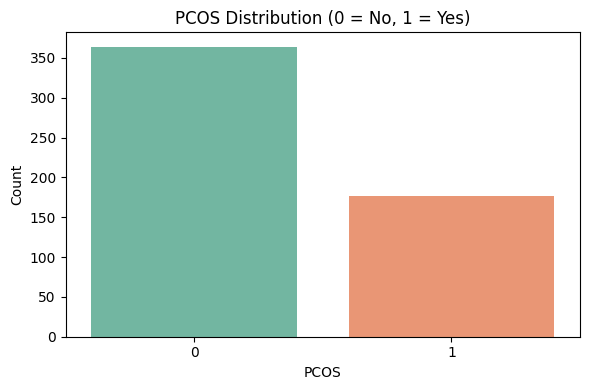

In [ ]:
# ================================
# EDA - CLASS DISTRIBUTION
# ================================

print("PCOS Distribution:")
print(data['PCOS (Y/N)'].value_counts())
print(f"\nPCOS % : {data['PCOS (Y/N)'].mean()*100:.2f}%")

plt.figure(figsize=(6,4))
sns.countplot(x='PCOS (Y/N)', data=data, palette='Set2')
plt.title('PCOS Distribution (0 = No, 1 = Yes)')
plt.xlabel('PCOS')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

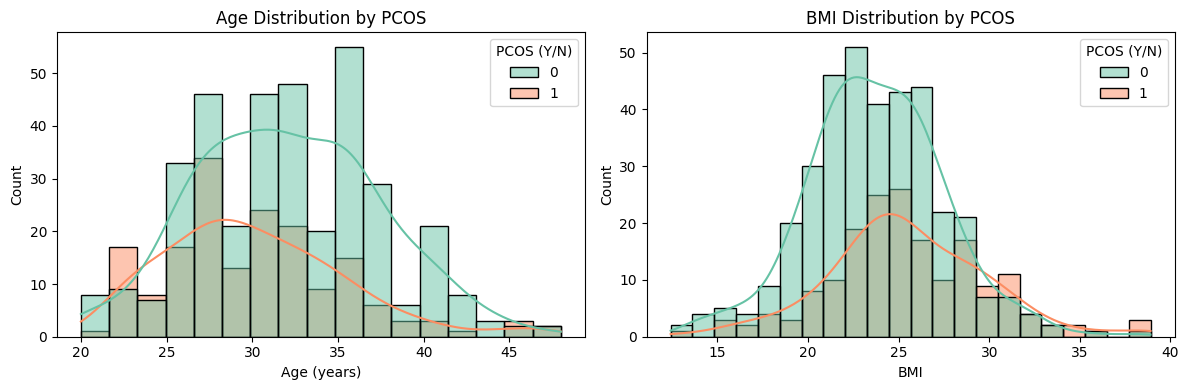

In [ ]:
# ================================
# EDA - AGE & BMI DISTRIBUTION
# ================================

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Age distribution
sns.histplot(data=data, x='Age (yrs)', hue='PCOS (Y/N)',
             palette='Set2', ax=axes[0], kde=True)
axes[0].set_title('Age Distribution by PCOS')
axes[0].set_xlabel('Age (years)')

# BMI distribution
sns.histplot(data=data, x='BMI', hue='PCOS (Y/N)',
             palette='Set2', ax=axes[1], kde=True)
axes[1].set_title('BMI Distribution by PCOS')
axes[1].set_xlabel('BMI')

plt.tight_layout()
plt.show()

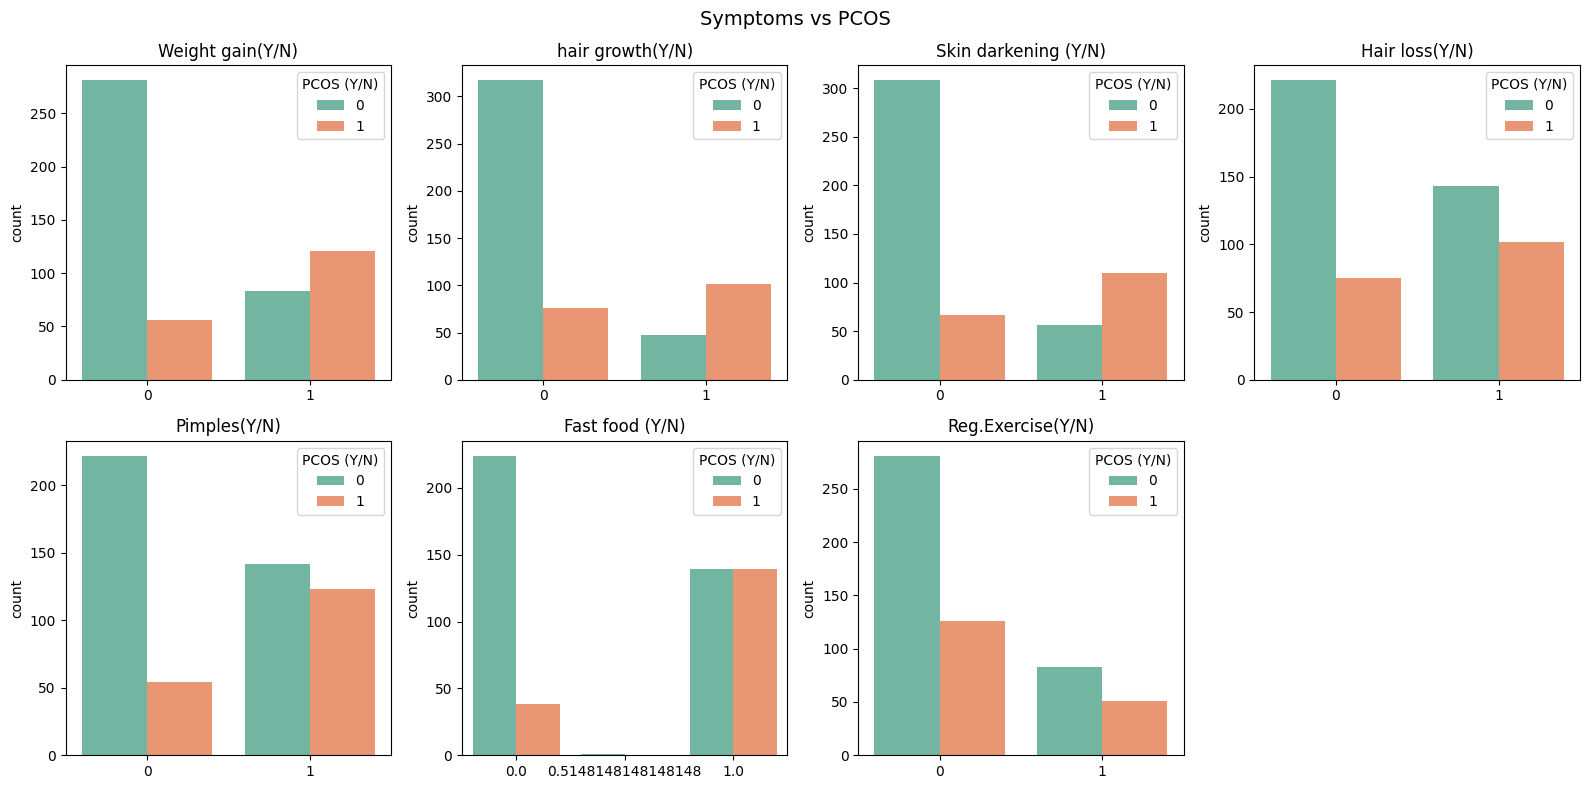

In [ ]:
# ================================
# EDA - SYMPTOMS ANALYSIS
# ================================

symptoms = ['Weight gain(Y/N)', 'hair growth(Y/N)',
            'Skin darkening (Y/N)', 'Hair loss(Y/N)',
            'Pimples(Y/N)', 'Fast food (Y/N)', 'Reg.Exercise(Y/N)']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, symptom in enumerate(symptoms):
    sns.countplot(x=symptom, hue='PCOS (Y/N)',
                  data=data, palette='Set2', ax=axes[i])
    axes[i].set_title(symptom)
    axes[i].set_xlabel('')

# Hide last empty plot
axes[7].set_visible(False)

plt.suptitle('Symptoms vs PCOS', fontsize=14)
plt.tight_layout()
plt.show()

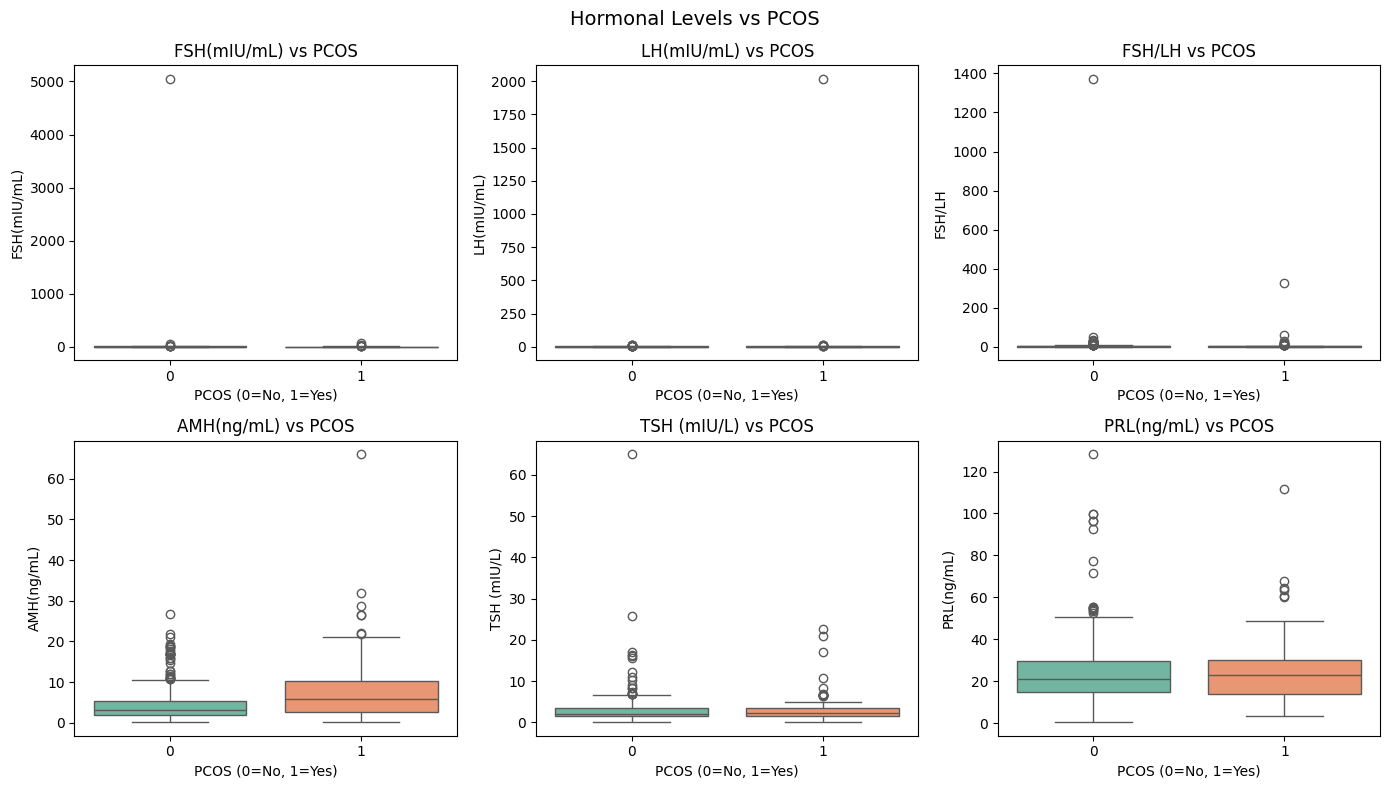

In [ ]:
# ================================
# EDA - HORMONAL LEVELS
# ================================

hormones = ['FSH(mIU/mL)', 'LH(mIU/mL)',
            'FSH/LH', 'AMH(ng/mL)',
            'TSH (mIU/L)', 'PRL(ng/mL)']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, hormone in enumerate(hormones):
    sns.boxplot(x='PCOS (Y/N)', y=hormone,
                data=data, palette='Set2', ax=axes[i])
    axes[i].set_title(f'{hormone} vs PCOS')
    axes[i].set_xlabel('PCOS (0=No, 1=Yes)')

plt.suptitle('Hormonal Levels vs PCOS', fontsize=14)
plt.tight_layout()
plt.show()

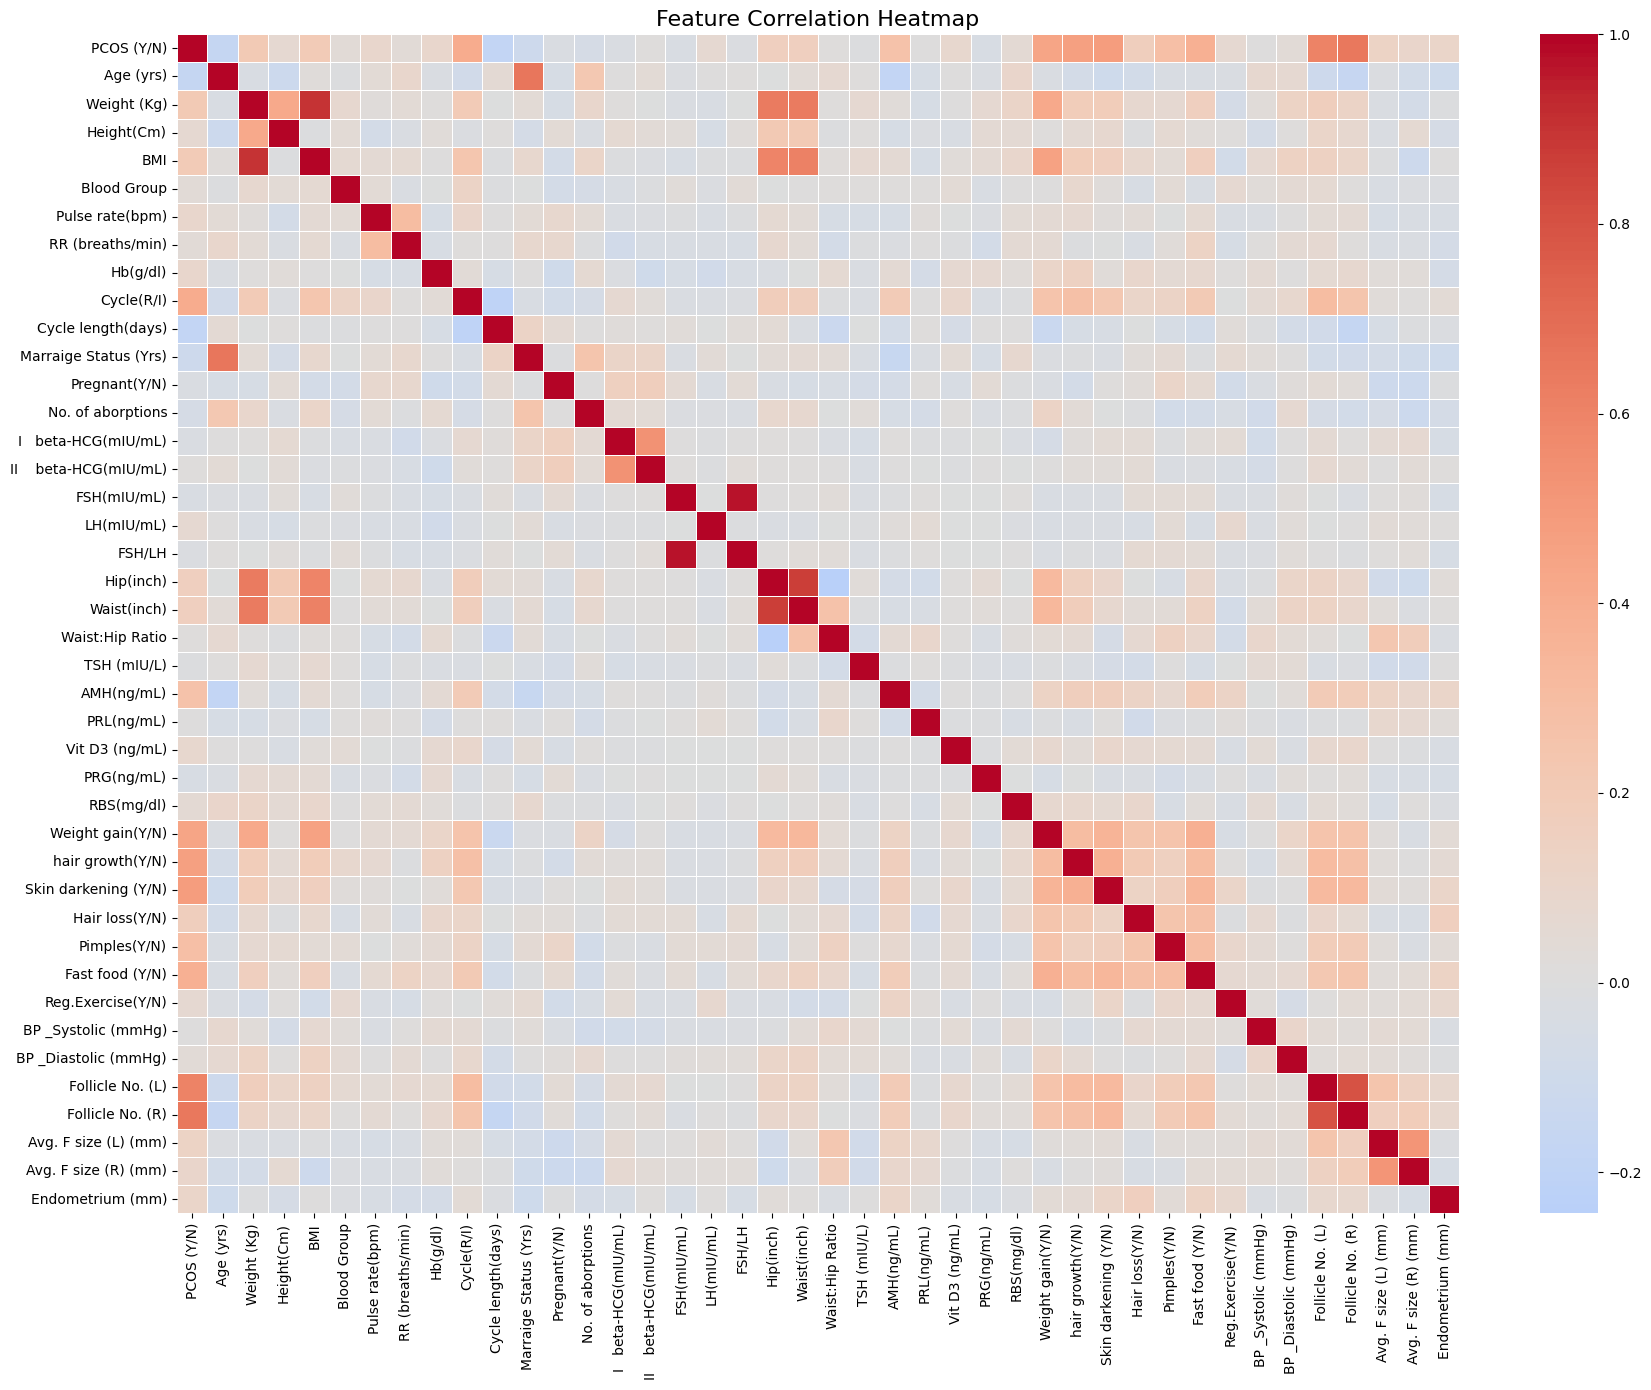

In [ ]:
# ================================
# EDA - CORRELATION HEATMAP
# ================================

plt.figure(figsize=(18, 14))
correlation = data.corr()
sns.heatmap(correlation,
            annot=False,
            cmap='coolwarm',
            center=0,
            linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=16)
plt.tight_layout()
plt.show()

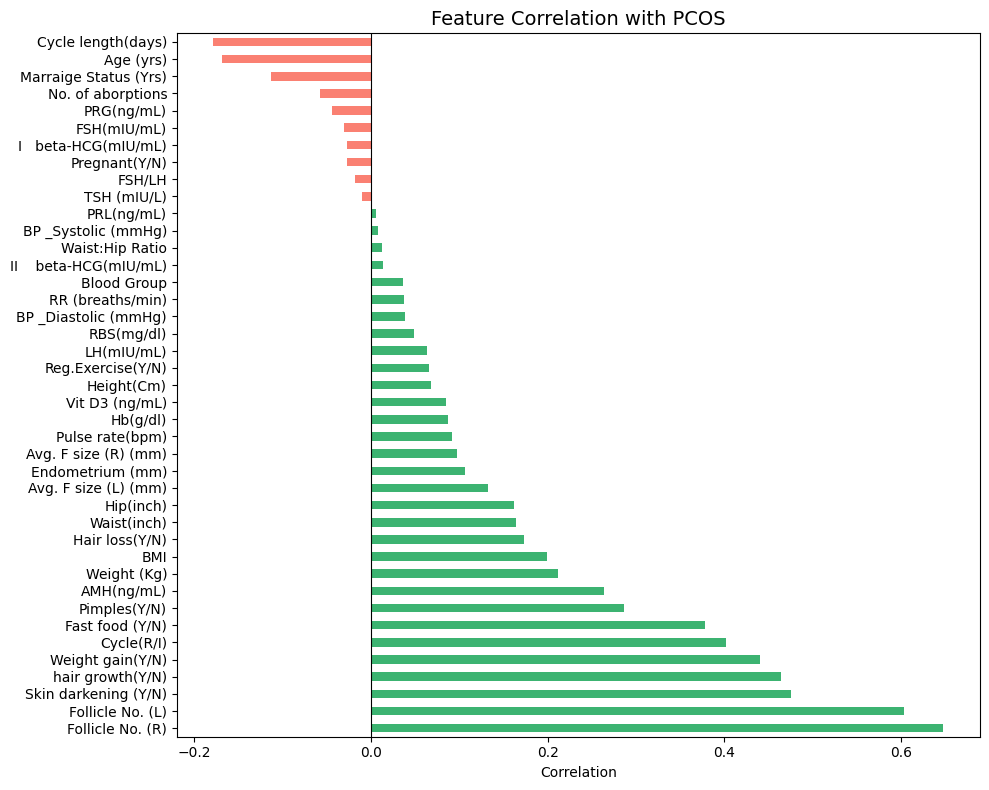


Top 10 Positively Correlated Features:
Follicle No. (R)        0.648327
Follicle No. (L)        0.603346
Skin darkening (Y/N)    0.475733
hair growth(Y/N)        0.464667
Weight gain(Y/N)        0.441047
Cycle(R/I)              0.401644
Fast food (Y/N)         0.377763
Pimples(Y/N)            0.286077
AMH(ng/mL)              0.263745
Weight (Kg)             0.211938
Name: PCOS (Y/N), dtype: float64

Top 5 Negatively Correlated Features:
PRG(ng/mL)              -0.043834
No. of aborptions       -0.057158
Marraige Status (Yrs)   -0.112681
Age (yrs)               -0.168513
Cycle length(days)      -0.178480
Name: PCOS (Y/N), dtype: float64


In [ ]:
# ================================
# EDA - TOP CORRELATED FEATURES WITH PCOS
# ================================

pcos_corr = data.corr()['PCOS (Y/N)'].drop('PCOS (Y/N)').sort_values(ascending=False)

plt.figure(figsize=(10, 8))
pcos_corr.plot(kind='barh', color=['salmon' if x < 0 else 'mediumseagreen' for x in pcos_corr])
plt.title('Feature Correlation with PCOS', fontsize=14)
plt.xlabel('Correlation')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print("\nTop 10 Positively Correlated Features:")
print(pcos_corr.head(10))
print("\nTop 5 Negatively Correlated Features:")
print(pcos_corr.tail(5))

In [ ]:
# ================================
# FEATURE SELECTION + SPLIT
# ================================

# Drop weakly correlated features
weak_features = ['Marraige Status (Yrs)', 'RR (breaths/min)',
                 'Pulse rate(bpm)', 'Blood Group', 'Pregnant(Y/N)']

X = data.drop(['PCOS (Y/N)'] + weak_features, axis=1)
y = data['PCOS (Y/N)']

print("Features after selection:", X.shape)
print("Dropped features:", weak_features)
print("\nClass distribution before SMOTE:")
print(y.value_counts())

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("\nTrain size:", X_train.shape)
print("Test size:", X_test.shape)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n✅ Data split and scaled!")

Features after selection: (541, 36)
Dropped features: ['Marraige Status (Yrs)', 'RR (breaths/min)', 'Pulse rate(bpm)', 'Blood Group', 'Pregnant(Y/N)']

Class distribution before SMOTE:
PCOS (Y/N)
0    364
1    177
Name: count, dtype: int64

Train size: (432, 36)
Test size: (109, 36)

✅ Data split and scaled!


Before SMOTE:
PCOS (Y/N)
0    291
1    141
Name: count, dtype: int64

After SMOTE:
PCOS (Y/N)
0    291
1    291
Name: count, dtype: int64


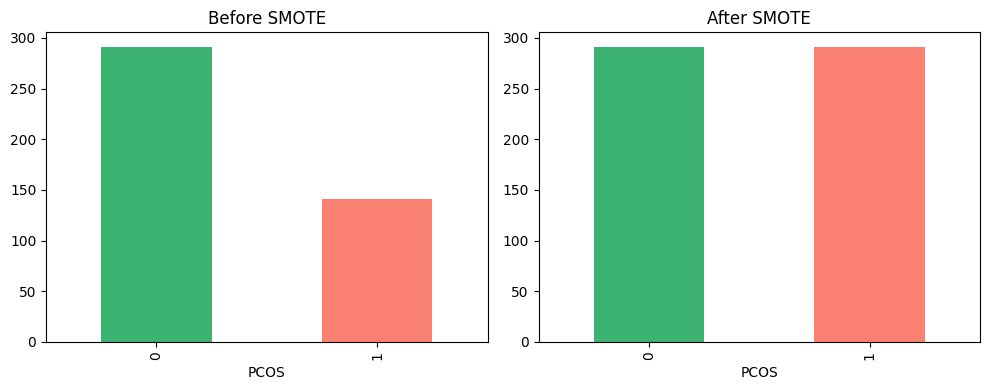

In [ ]:
# ================================
# SMOTE - HANDLE CLASS IMBALANCE
# ================================

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("Before SMOTE:")
print(pd.Series(y_train).value_counts())

print("\nAfter SMOTE:")
print(pd.Series(y_train_smote).value_counts())

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

pd.Series(y_train).value_counts().plot(kind='bar', ax=axes[0],
                                        color=['mediumseagreen', 'salmon'])
axes[0].set_title('Before SMOTE')
axes[0].set_xlabel('PCOS')

pd.Series(y_train_smote).value_counts().plot(kind='bar', ax=axes[1],
                                              color=['mediumseagreen', 'salmon'])
axes[1].set_title('After SMOTE')
axes[1].set_xlabel('PCOS')

plt.tight_layout()
plt.show()

In [ ]:
# ================================
# MODEL TRAINING - RANDOM FOREST
# ================================

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_smote, y_train_smote)

print("✅ Model Trained!")

# Predictions
y_pred = model.predict(X_test_scaled)

# Accuracy
print("\nAccuracy:", round(accuracy_score(y_test, y_pred) * 100, 2), "%")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

✅ Model Trained!

Accuracy: 90.83 %

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.95      0.93        73
           1       0.88      0.83      0.86        36

    accuracy                           0.91       109
   macro avg       0.90      0.89      0.89       109
weighted avg       0.91      0.91      0.91       109



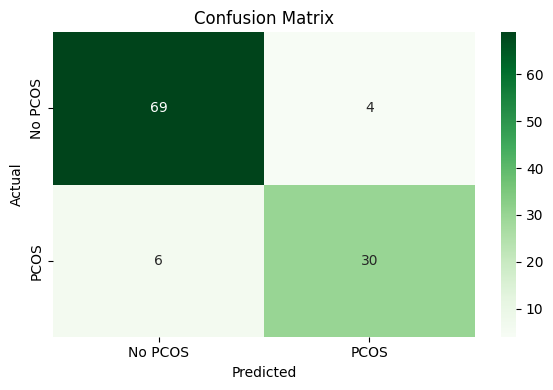

In [ ]:
# ================================
# CONFUSION MATRIX
# ================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No PCOS', 'PCOS'],
            yticklabels=['No PCOS', 'PCOS'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

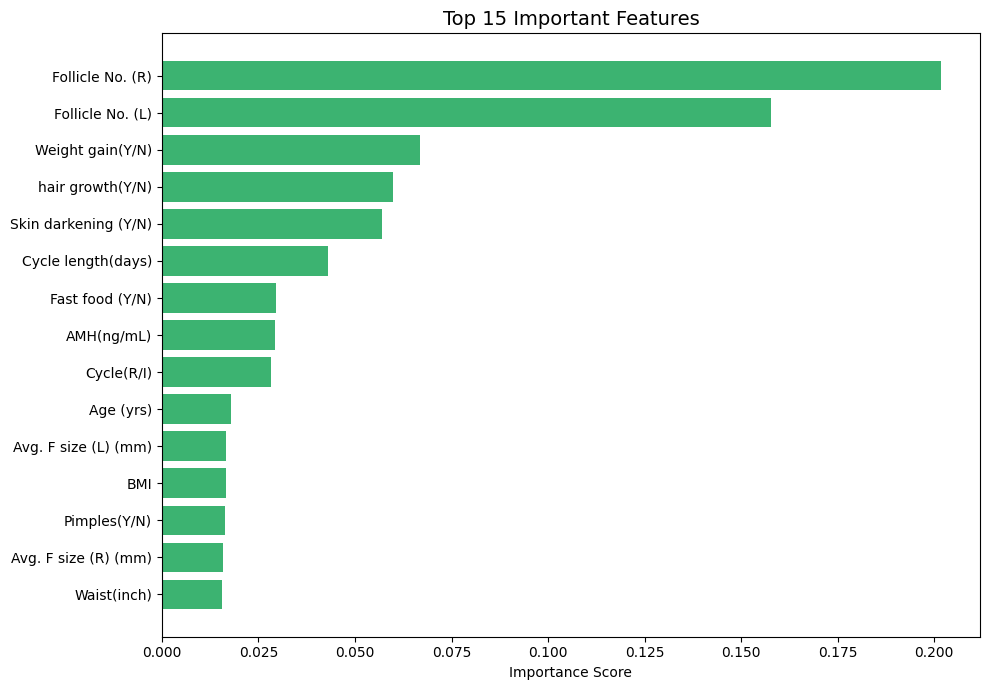

In [ ]:
# ================================
# FEATURE IMPORTANCE
# ================================

feature_names = X.columns
importances = model.feature_importances_

feat_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=True).tail(15)

plt.figure(figsize=(10, 7))
plt.barh(feat_df['Feature'], feat_df['Importance'], color='mediumseagreen')
plt.title('Top 15 Important Features', fontsize=14)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [ ]:
# ================================
# SAVE MODEL & SCALER
# ================================

with open('pcos_model.pkl', 'wb') as f:
    pickle.dump(model, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save feature names too
with open('feature_names.pkl', 'wb') as f:
    pickle.dump(list(X.columns), f)

print("pcos_model.pkl saved!")
print("scaler.pkl saved!")
print("feature_names.pkl saved!")
print("\nFeatures used:", list(X.columns))

pcos_model.pkl saved!
scaler.pkl saved!
feature_names.pkl saved!

Features used: ['Age (yrs)', 'Weight (Kg)', 'Height(Cm)', 'BMI', 'Hb(g/dl)', 'Cycle(R/I)', 'Cycle length(days)', 'No. of aborptions', 'I   beta-HCG(mIU/mL)', 'II    beta-HCG(mIU/mL)', 'FSH(mIU/mL)', 'LH(mIU/mL)', 'FSH/LH', 'Hip(inch)', 'Waist(inch)', 'Waist:Hip Ratio', 'TSH (mIU/L)', 'AMH(ng/mL)', 'PRL(ng/mL)', 'Vit D3 (ng/mL)', 'PRG(ng/mL)', 'RBS(mg/dl)', 'Weight gain(Y/N)', 'hair growth(Y/N)', 'Skin darkening (Y/N)', 'Hair loss(Y/N)', 'Pimples(Y/N)', 'Fast food (Y/N)', 'Reg.Exercise(Y/N)', 'BP _Systolic (mmHg)', 'BP _Diastolic (mmHg)', 'Follicle No. (L)', 'Follicle No. (R)', 'Avg. F size (L) (mm)', 'Avg. F size (R) (mm)', 'Endometrium (mm)']
